<center><h1> Conditional Generation for TS <h1><center>

In [14]:
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
import torch
import copy
import torch.nn.functional as F
from tqdm import tqdm 

# 1. Data Generating process  

Consider the folloqing autoregressive process with normal innovations: 

$$x_t = \phi x_{k-1} + \eta_t \qquad \eta_t \sim \mathcal{N}(0,\sigma^2I)$$

We want to sample from the conditional distribution $q(x_t|x_{0:(k-1)})$. For an AR this is becomes just:

$$q(x_t|x_{k}) = \mathcal{N}(\phi x_{k-1}, \sigma^2I)$$

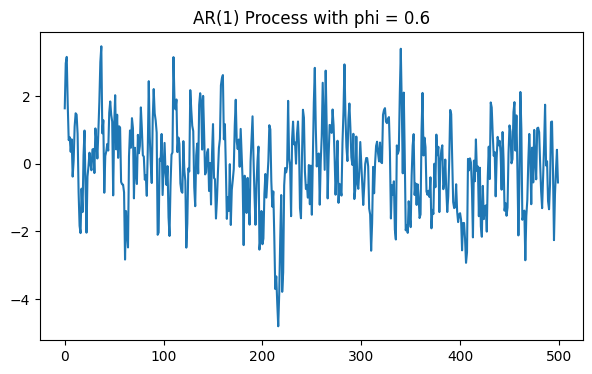

In [ ]:
from utils.ArProcess import AR_normal, AR_studentt
phi = 0.6
ar = AR_studentt(phi=phi, df=8)
ar = AR_normal(phi=phi, sigma=1)
x = ar.sample_prev(k=1000)

plt.figure(figsize=(7,4))
plt.title(f"AR(1) Process with phi = {phi}")
plt.plot(x[-500:,0], label="x_t")
plt.show()

# 2. Diffusion Process

## 2.1. Beta Schedule

Note that the scheduler returns a tensor of size $T$. Therefore to get the timestep $k$ of the diffusion process one have to call $k-1$. The beta implementation is taken from: https://github.com/KAIST-Visual-AI-Group/Diffusion-2025-Assignment1-DDPM-DDIM/blob/main/DDPM_DDIM.ipynb 

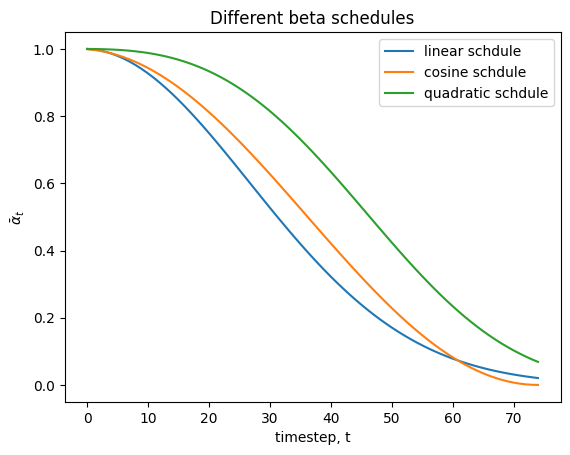

In [16]:
from utils.diffModules import BaseScheduler
steps = 75

linear_scheduler = BaseScheduler(num_train_timesteps = steps,mode = "linear")
cosine_scheduler = BaseScheduler(num_train_timesteps = steps,mode = "cosine")
quad_scheduler = BaseScheduler(num_train_timesteps = steps,mode = "quad")

plt.plot(linear_scheduler.alpha_bar, label = "linear schdule")
plt.plot(cosine_scheduler.alpha_bar, label = "cosine schdule")
plt.plot(quad_scheduler.alpha_bar, label = "quadratic schdule")
plt.title("Different beta schedules")
plt.ylabel(r"$\bar{\alpha}_t$")
plt.xlabel("timestep, t")
plt.legend()
plt.show()

## 2.2. Forward Process

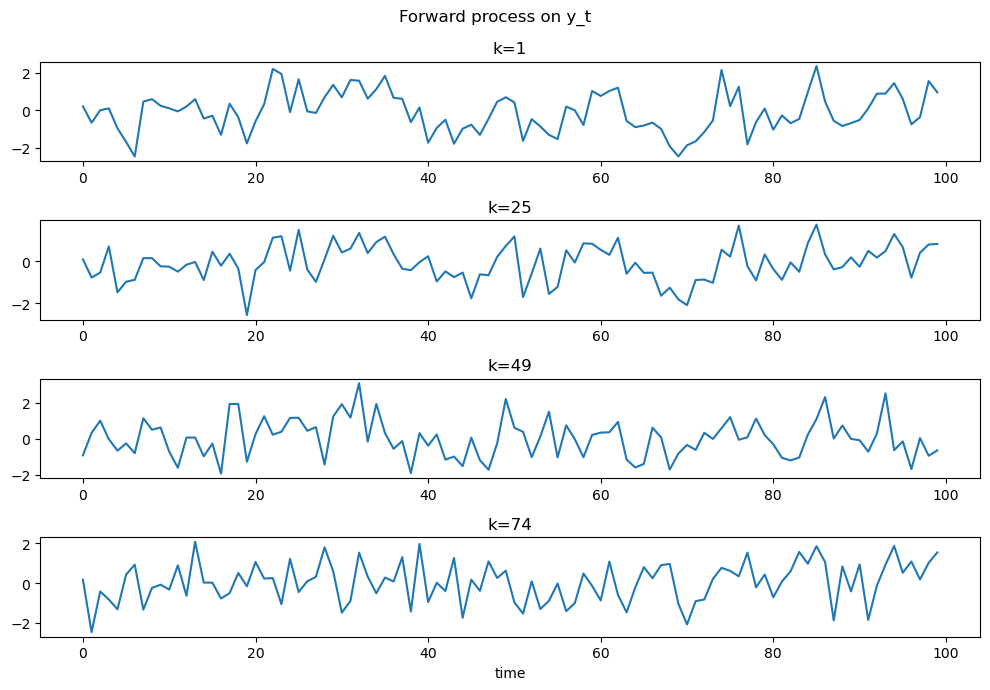

In [ ]:
from utils.diffModules import DDPM

xy = torch.from_numpy(x)
x_0 = xy[:,0:1]
y = xy[:,1:2]

steps = 75
cosine_scheduler = BaseScheduler(num_train_timesteps = steps, mode = "linear")
ddpm = DDPM(scheduler=cosine_scheduler)

figure, ax = plt.subplots(4,1, figsize=(10,7))
# Noising x_t
for i, k in enumerate(np.linspace(1,steps-1,4)):
    tt = torch.full(x_0.shape,int(k))
    x_t, _ = ddpm.q_sample(x_0=x_0, k=tt)
    ax[i].set_title(f"k={int(k)}")
    ax[i].plot(x_t[-100:])
plt.xlabel("time")
plt.suptitle(f"Forward process on y_t")
plt.tight_layout()
plt.show()

Checking if the $y^{(K)}_t$ series is white noise. Looks like even 50 steps are enough using the modified cosine schedule for an Ar(1)

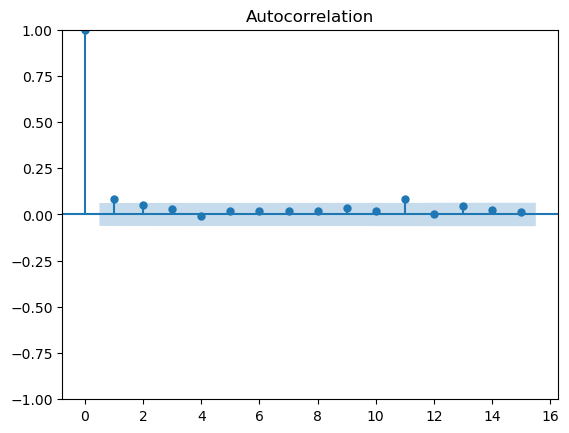

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

steps = 75
cosine_scheduler = BaseScheduler(num_train_timesteps = steps, mode = "linear")
ddpm = DDPM(scheduler=cosine_scheduler)

tt = torch.full(x_0.shape,steps-1)
x_t, _ = ddpm.q_sample(x_0=x_0, k=tt)

plot_acf(x_t.numpy(), lags=15)
plt.show()

In [129]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(x_t, lags=[5, 10, 15]) 

print("Ljung-Box test p-values:")
print(lb_test)

Ljung-Box test p-values:
      lb_stat  lb_pvalue
5    2.596137   0.761952
10  17.955666   0.055716
15  21.969438   0.108608


## 2.3. Train Network

In [ ]:
def training(
    xy_0: torch.Tensor,
    model: nn.Module,
    diffusion: DDPM,
    epochs: int = 250,
    batch_size: int = 256,
    lr: float = 1e-3,
    patience: int = 20,
    print_loss: bool = False
    ):
    model.train()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    num_batches = xy_0.shape[0] // batch_size
    losses = []

    # Patience and best model
    best_loss        = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in tqdm(range(epochs), leave=False):
        perm = torch.randperm(xy_0.shape[0])
        xy_0 = xy_0[perm]
        epoch_loss = 0.0

        for b in range(num_batches):
            batch = xy_0[b * batch_size : (b + 1) * batch_size]
            x0 = batch[:, 0:1]
            y  = batch[:, 1:2]

            k = torch.randint(0, diffusion.scheduler.num_train_timesteps, (batch_size,))
            x_t, noise = diffusion.q_sample(x0, k)

            eps_pred = model(x_t, k, y=y) 

            loss = F.mse_loss(eps_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / num_batches
        losses.append(avg_loss)

        # check if loss is less than best loss. 
        if avg_loss < best_loss:
            best_loss        = avg_loss
            best_model_state = copy.deepcopy(model.state_dict()) 
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 50 == 0 and print_loss:
            print(f"Epoch {epoch}/{epochs} | Loss: {avg_loss:.4f} | Patience: {patience_counter}/{patience}")

        # early stopping
        if patience_counter >= patience:
            if print_loss:
                print(f"Early stopping at epoch {epoch} | Best loss: {best_loss:.4f}")
            break

    # restore best model
    model.load_state_dict(best_model_state)
    
    return losses, best_loss

In [ ]:
from utils.denoisingRNN import DenoisingNet 

# Draw from p(x,y) 
phi = 0.6
# ar = AR_studentt(phi=phi, df=8)
ar = AR_normal(phi=phi, sigma=1)
x = ar.sample_prev(T=20000)

# Define xy, x and y
xy = torch.from_numpy(x).float()
x_0 = xy[:,0:1]
y = xy[:,1:2]

steps = 75
cosine_scheduler = BaseScheduler(num_train_timesteps = steps, mode = "cosine")
ddpm = DDPM(scheduler=cosine_scheduler)

# Define the model
model = DenoisingNet(dim_in=1, dim_out=1, dim_hids=[64, 128, 128, 64], num_timesteps=steps)

losses, best_loss = training(xy_0 = xy, model = model,
    diffusion = ddpm,
    epochs = 100,
    batch_size = 256,
    lr = 1e-3,
    print_loss = True
    )

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:00<00:42,  2.32it/s]

Epoch 0/100 | Loss: 0.6252 | Patience: 0/20


Early stopping at epoch 23 | Best loss: 0.4839


In [134]:
torch.save(model.state_dict(), "AR_denoising_network.pth") 

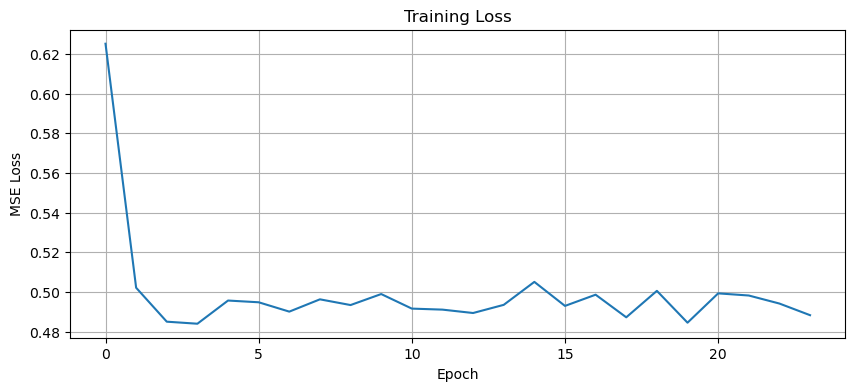

In [135]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

# 3. Inference

In [136]:
# Load the trained model
model = DenoisingNet(dim_in=1, dim_out=1, dim_hids=[64, 128, 128, 64], num_timesteps=steps)
model.load_state_dict(torch.load("AR_denoising_network.pth", weights_only=True))

<All keys matched successfully>

We use the reverse process of DDPM (could also use DDIM). 

In [ ]:
# Theoretical conditional density
x_cond = -1
x_grid, p = ar.conditional_pdf(x, c=x_cond)

# DDPM conditional draw
x_hat, history = ddpm.reverse_sampling(model = model, n_samples = 10000, y=x_cond)

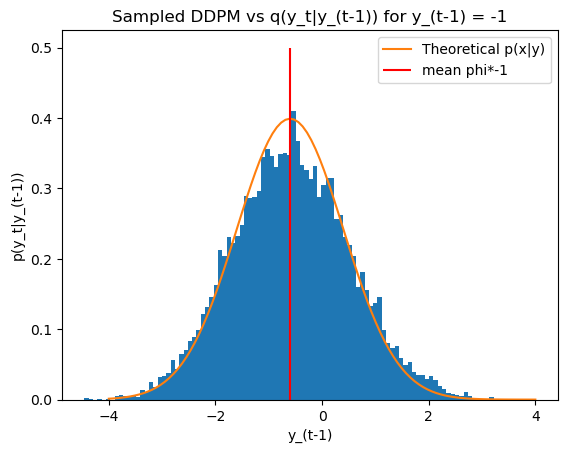

In [120]:
plt.hist(x_hat.detach().numpy(), bins = 100, density=True)
plt.plot(x_grid, p, label = "Theoretical p(x|y)")
plt.title(f"Sampled DDPM vs q(y_t|y_(t-1)) for y_(t-1) = {x_cond}")
plt.vlines(x=phi*x_cond,ymin=0,ymax=0.5, colors="red", label=f"mean phi*{x_cond}")
plt.ylabel("p(y_t|y_(t-1))")
plt.xlabel("y_(t-1)")
plt.legend()
plt.show()

In [123]:
ddpm = DDPM(scheduler=cosine_scheduler)
steps_to_plot = [74, 50, 25, 10, 1]
x_hat, history = ddpm.reverse_sampling(model = model, n_samples = 10000, y=x_cond, steps_to_plot=steps_to_plot)

IndexError: list index out of range

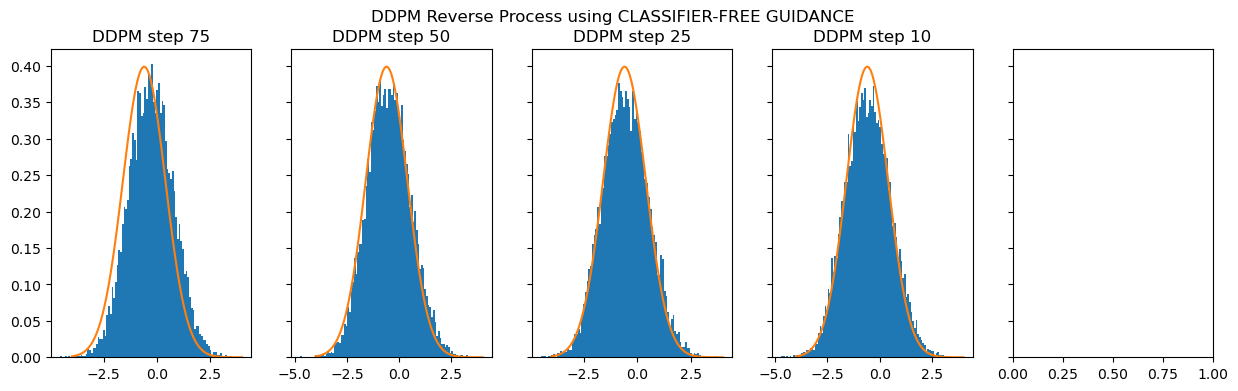

In [124]:
fig, ax = plt.subplots(1,len(steps_to_plot),figsize=(15,4),sharey=True)
plt.suptitle("DDPM Reverse Process using CLASSIFIER-FREE GUIDANCE")
for i, t in enumerate(steps_to_plot):
    ax[i].hist(history[i].numpy(), bins = 100, density=True)
    ax[i].set_title(f"DDPM step {t}")
    ax[i].plot(x_grid, p, label = "Theoretical p(x|y)")
plt.show()

# SAMPLE A TRAJECTORY

In [85]:
def sample_trajectory(ddpm : DDPM, model : nn.Module, N : int, y_cond : float):
    sampled_trajectory = np.zeros(N)
    for i in tqdm(range(N), leave=False):
        y_hat, _ = ddpm.reverse_sampling(model = model, n_samples = 1, y=y_cond, steps_to_plot=[])
        y_cond = float(y_hat)
        sampled_trajectory[i] = y_cond
    return sampled_trajectory

In [86]:
y_ddpm = sample_trajectory(ddpm, model=model, N=2000, y_cond =-1)

# Evaluation

### Plot the sampled trajectory

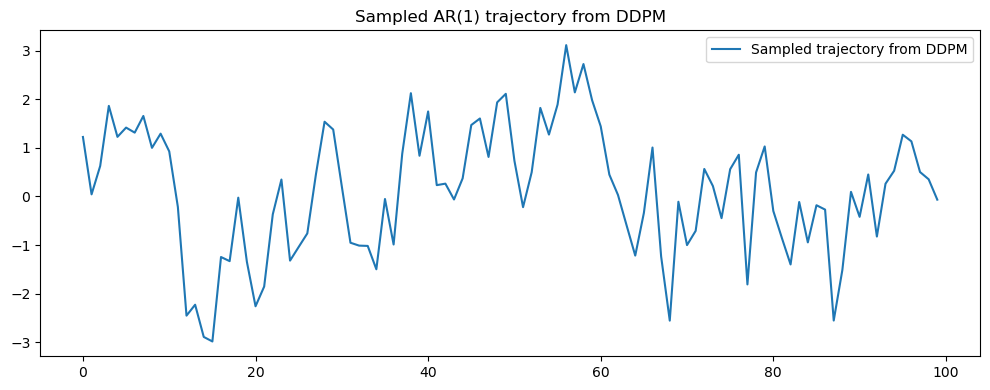

In [55]:
plt.figure(figsize=(10, 4))
plt.title("Sampled AR(1) trajectory from DDPM")
plt.plot(y_ddpm[-100:], label = "Sampled trajectory from DDPM")
plt.legend()
plt.tight_layout()
plt.show()

### Fit an AR(1) model and estimate $\phi$

In [87]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

model_ar = AutoReg(y_ddpm, lags=1, trend='n')
results = model_ar.fit()

# Print summary
print(results.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                 2000
Model:                     AutoReg(1)   Log Likelihood               -2840.162
Method:               Conditional MLE   S.D. of innovations              1.002
Date:                Sun, 08 Mar 2026   AIC                           5684.324
Time:                        15:00:35   BIC                           5695.525
Sample:                             1   HQIC                          5688.437
                                 2000                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
y.L1           0.6590      0.017     39.170      0.000       0.626       0.692
                                    Roots                                    
                  Real          Imaginary           M

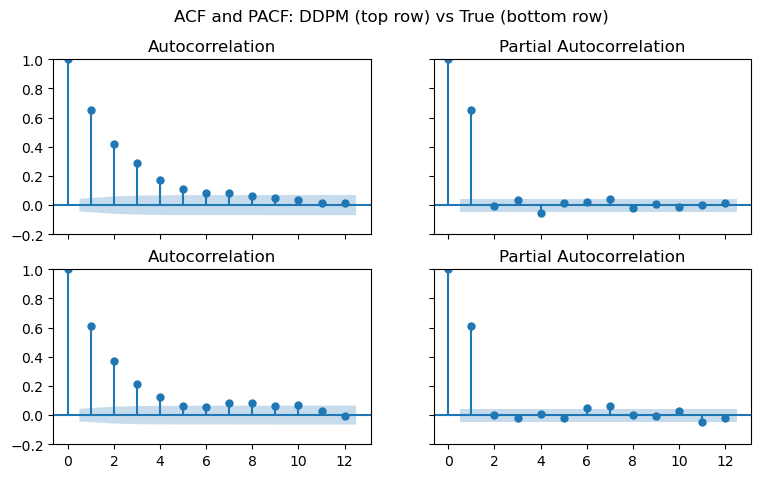

In [88]:
x_0 = ar.generate_trajectory(T=y_ddpm.shape[0]).flatten()

# Plot ACF and PACF
fig, ax = plt.subplots(2, 2, figsize=(9, 5),sharey=True, sharex=True)
plot_acf(y_ddpm, lags=12, ax=ax[0,0])
plot_pacf(y_ddpm, lags=12, ax=ax[0,1])
plot_acf(x_0, lags=12, ax=ax[1,0])
plot_pacf(x_0, lags=12, ax=ax[1,1])
plt.suptitle("ACF and PACF: DDPM (top row) vs True (bottom row)")
plt.ylim([-0.2,1])
plt.show()

## WASSERSTEIN 1

In [ ]:
from utils.ArProcess import AR1
import ot

def get_chunks(x, k):
    """For an array of shape [T,] returns an array of shape [T-k,k] with the kth adiacent ts obs"""
    return np.array([x[i:i+k] for i in range(len(x) - k)])

def wasserstein_chunks(ar, y_ddpm, k : int):
    """W_1 btw the AR(1) ground truth and DDPM traj"""
    y_0 = ar.generate_trajectory(T=y_ddpm.shape[0]).flatten()
    y_chunk_ddpm = get_chunks(y_ddpm, k)
    y_chunk_0 = get_chunks(y_0, k)
    assert y_chunk_0.shape == y_chunk_ddpm.shape
    M = ot.dist(y_chunk_ddpm, y_chunk_0, metric='euclidean')
    W = ot.emd2([], [], M) 
    return W

def wasserstein_1(ddpm : DDPM, ar : AR1, no_trj : int, model : nn.Module, N : int, y_cond : float, k :int=6):
    score = []
    for _ in range(no_trj):
        y_ddpm = sample_trajectory(ddpm, model, N, y_cond)
        w_1 = wasserstein_chunks(ar, y_ddpm, k)
        score.append(w_1)
    return np.mean(score)

def wasserstein_ar(ar, T, k, n_sim=20):
    """W_1 btw two AR(1) trajectories"""
    scores = []
    for _ in range(n_sim):
        y1 = ar.generate_trajectory(T=T).flatten()
        scores.append(wasserstein_chunks(ar, y1, k))
    return np.mean(scores)

### WASSERTSEIN (one draw for each)

In [ ]:
w_ddpm = wasserstein_chunks(ar = ar, y_ddpm = y_ddpm, k=6)
print("W_1 btw DDPM traj and ground truth", w_ddpm)
w_truth = wasserstein_ar(ar = ar, T = 2000, k=6, n_sim=20)
print("W_1 btw two ground truth", w_truth)

W_1 btw DDPM traj and ground truth 1.1106000369376638
W_1 btw two ground truth 1.0020419722381702


### WASSERTSEIN (many draw for each)

In [ ]:
w_ddpm = wasserstein_1(ddpm, ar, no_trj = 5, model=model, N = 200, y_cond=0.5)
print(w_ddpm)
w_truth = wasserstein_ar(ar = ar, T = 2000, k=6, n_sim=5)
print(w_truth)

1.6480190260974346
1.0107376645928539
